
# Simple Linear Regression

Estimated time needed: **15** minutes
    

## Objectives

After completing this lab, you will be able to:

* Use scikit-learn to implement simple linear regression
* Create, train, and test a linear regression model on real data


### Import needed packages


For this lab, you will need to have the following packages:
 - NumPy
 - Matplotlib
 - Pandas
 - Scikit-learn

To avoid issues importing these libraries, you may execute the following cell to ensure they are available.


In [1]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

Now, you can import these libraries.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

%matplotlib inline

## Load the data
The dataset you will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.


In [3]:

url= "FuelConsumptionCo2.csv"
df=pd.read_csv(url)

In [4]:
# verify successful load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
316,2014,DODGE,DART,MID-SIZE,2.4,4,M6,X,10.5,6.7,8.8,32,202
410,2014,FORD,FUSION,MID-SIZE,1.6,4,M6,X,9.4,6.4,8.1,35,186
961,2014,SUBARU,TRIBECA AWD,SUV - SMALL,3.6,6,AS5,X,14.7,11.1,13.1,22,301
1058,2014,VOLVO,S60 AWD,COMPACT,3.0,6,AS6,X,13.2,9.5,11.5,25,264
802,2014,MINI,COOPER S ROADSTER,TWO-SEATER,1.6,4,A6,Z,9.3,7.0,8.3,34,191



## Understand the data

### `FuelConsumption.csv`:
Bạn sẽ sử dụng một tập dữ liệu về mức tiêu thụ nhiên liệu, FuelConsumption.csv, trong đó chứa các thông tin đánh giá mức tiêu thụ nhiên liệu theo từng mẫu xe và lượng khí thải CO₂ ước tính cho các xe hạng nhẹ mới được bán lẻ tại Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

Nhiệm vụ của bạn là tạo một mô hình hồi quy tuyến tính đơn sử dụng một trong các đặc trưng này để dự đoán lượng khí thải CO₂ của những chiếc xe chưa được quan sát, dựa trên đặc trưng đó. 


### Khám phá dữ liệu

Đầu tiên, hãy xem xét bản tóm tắt thống kê của dữ liệu.


In [5]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Từ dữ liệu, chúng ta có thể thấy rằng phần lớn các xe (khoảng 75%) có mức tiêu thụ nhiên liệu trong khoảng 11 đến 31 MPG.
Tuy nhiên, có một xe có giá trị 60 MPG, cao hơn rất nhiều so với phần còn lại.

Điều này có thể là:

một giá trị hợp lệ đối với một chiếc xe hiệu suất cao hoặc xe hybrid,
hoặc

có thể là một điểm ngoại lệ (outlier) hoặc lỗi nhập liệu.

Biến MODELYEAR có độ lệch chuẩn bằng 0, vì vậy biến này không mang thông tin hữu ích (không có sự biến thiên trong dữ liệu).


#### Select features
Hãy chọn một vài đặc trưng (features) có thể phản ánh lượng khí thải CO₂ để phân tích sâu hơn


In [6]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
645,3.0,6,17.4,278
619,2.0,4,9.3,214
263,5.3,8,13.8,317
377,3.7,6,12.3,283
318,2.0,4,12.2,195
815,1.6,4,8.0,184
79,2.0,4,6.7,181
111,4.4,8,12.7,292
121,4.4,8,13.8,317


#### Visualize features
Consider the histograms for each of these features.


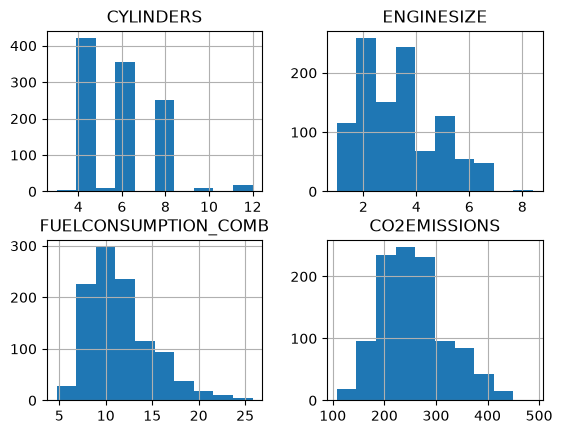

In [7]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

Như ta có thể thấy, phần lớn các động cơ có 4, 6 hoặc 8 xi-lanh, và dung tích động cơ nằm trong khoảng từ 2 đến 4 lít.
Như ta có thể dự đoán, mức tiêu thụ nhiên liệu tổng hợp và lượng khí thải CO₂ có phân phối rất giống nhau.

Hãy hiển thị một số biểu đồ scatter giữa các đặc trưng này và lượng CO₂ thải ra, để xem mức độ tuyến tính trong mối quan hệ giữa chúng.
Scatter plot là gì?

Mỗi điểm trên biểu đồ tượng trưng cho một bản ghi (một hàng dữ liệu).

Trục X biểu diễn biến số thứ nhất.

Trục Y biểu diễn biến số thứ hai.

biểu đồ scatter (scatter plot) thể hiện mối quan hệ giữa:

Trục X: FUELCONSUMPTION_COMB – mức tiêu thụ nhiên liệu tổng hợp (kết hợp) của các mẫu xe

Trục Y: Emission – lượng khí thải CO₂ tương ứng

Mỗi dấu chấm màu xanh đại diện cho một chiếc xe trong dữ liệu.


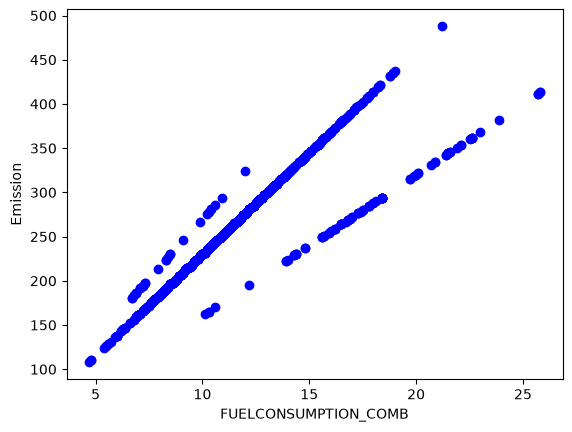

In [8]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

Nhận xét từ biểu đồ
✔️ 1. Mối quan hệ tuyến tính rất rõ ràng

Ta có thể thấy xu hướng tổng thể:

Khi mức tiêu thụ nhiên liệu tăng → lượng khí thải CO₂ cũng tăng.

Các điểm dữ liệu nằm gần thành những đường thẳng, thể hiện mối quan hệ tuyến tính mạnh.

Điều này hoàn toàn hợp lý:
👉 Xe dùng nhiều nhiên liệu hơn → thải nhiều CO₂ hơn.



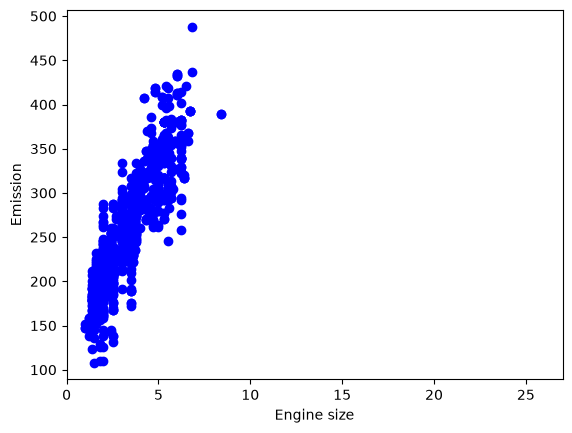

In [9]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

biểu đồ scatter (Engine size vs. Emission)
Biểu đồ này mô tả mối quan hệ giữa:

Trục X: Engine size – dung tích động cơ

Trục Y: Emission – lượng khí thải CO₂

Mỗi điểm xanh đại diện cho một mẫu xe.
Mối quan hệ tuyến tính rõ ràng

Ta thấy rằng khi dung tích động cơ tăng, lượng khí thải CO₂ cũng tăng.
Điều này tạo ra một xu hướng đi lên rất rõ rệt → chứng tỏ mối quan hệ tuyến tính mạnh.

Điều này hợp lý về mặt kỹ thuật:

Động cơ lớn → tiêu thụ nhiều nhiên liệu hơn

Tiêu thụ nhiều nhiên liệu → thải nhiều CO₂ hơn


#### Bài tập 1
Hãy vẽ biểu đồ giữa biến CYLINDER và lượng khí thải CO₂(CO2 Emission) để xem mối quan hệ giữa chúng có tuyến tính hay không.

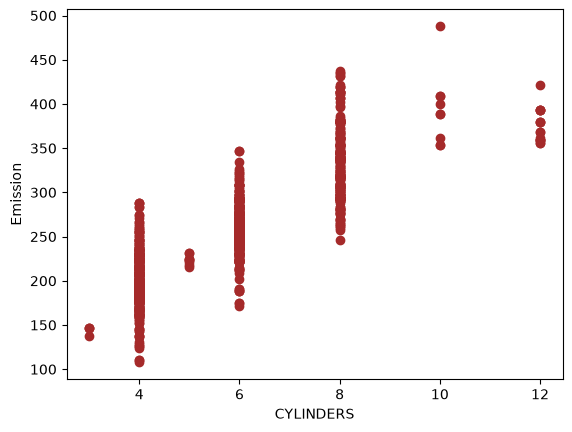

In [10]:
# write your code here

plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='brown')
plt.xlabel("CYLINDERS")
plt.ylabel("Emission")

plt.show()

### Nhận xét từ biểu đồ

✔️ **1. Có mối quan hệ thuận khá rõ giữa số xi-lanh và lượng khí thải**

Ta có thể thấy xu hướng tổng thể:

* Khi **số lượng xi-lanh (CYLINDERS) tăng → lượng khí thải (Emission) cũng có xu hướng tăng**.

Điều này khá hợp lý:
👉 **Động cơ có nhiều xi-lanh thường có dung tích và công suất lớn hơn → tiêu thụ nhiều nhiên liệu hơn → lượng khí thải cũng cao hơn.**

✔️ **2. Mối quan hệ không tuyến tính**

Các điểm dữ liệu tại cùng một số lượng xi-lanh vẫn có độ phân tán khá lớn, đặc biệt ở nhóm **4, 6 và 8 xi-lanh**.

👉 Điều này cho thấy **số xi-lanh có ảnh hưởng đến lượng khí thải, nhưng không phải là yếu tố duy nhất**. Các yếu tố khác như dung tích động cơ, mức tiêu thụ nhiên liệu hoặc loại xe cũng có thể ảnh hưởng đến Emis

### Trích xuất đặc trưng đầu vào và nhãn từ tập dữ liệu
Mặc dù engine size có thể chưa chắc là lựa chọn đặc trưng đầu vào tối ưu nhất, nhưng để minh họa, ta sẽ sử dụng dung tích động cơ để dự đoán lượng khí thải CO₂ bằng mô hình hồi quy tuyến tính.

Có thể bắt đầu bằng cách trích xuất đặc trưng đầu vào và biến mục tiêu, tức X và y, từ tập dữ liệu.


In [11]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

#### Tạo tập dữ liệu huấn luyện và kiểm tra
Tiếp theo, chia tập dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (testing set) một cách độc lập với nhau.
Huấn luyện mô hình hồi quy tuyến tính đơn trên tập huấn luyện và đánh giá khả năng tổng quát hóa của mô hình lên dữ liệu chưa từng thấy bằng cách dùng mô hình để dự đoán trên tập kiểm tra.

Vì kết quả thực tế của từng điểm dữ liệu trong tập kiểm tra đều có sẵn, ta có phương tiện để đánh giá độ chính xác ngoài mẫu (out-of-sample accuracy) của mô hình.

Bây giờ, ta cần chia dữ liệu một cách ngẫu nhiên thành tập train và test, trong đó:

sử dụng 80% dữ liệu để huấn luyện,

và 20% còn lại để kiểm tra.

Tỷ lệ được chọn phụ thuộc nhiều vào kích thước tập dữ liệu, nhưng tỷ lệ phổ biến cho test nằm trong khoảng 20% đến 30%.

Dữ liệu càng nhỏ, bạn càng cần nhiều dữ liệu dành cho tập train, vì với dữ liệu ít, mô hình rất dễ học nhầm các mẫu sai (spurious patterns).

Nhược điểm của việc sử dụng quá nhiều dữ liệu cho tập train là đánh giá khả năng tổng quát hóa sẽ kém ổn định hơn, vì tập test quá nhỏ.

Nói một cách đơn giản:
👉 Càng nhiều dữ liệu thì càng tốt.


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

1. train_test_split(X, y, ...)

X: tập đặc trưng đầu vào (input features)
→ Ví dụ: engine size

y: tập nhãn / mục tiêu (target labels)
→ Ví dụ: lượng CO₂ emission

Hàm này sẽ chia X và y đồng bộ, đảm bảo mỗi dòng X tương ứng với dòng y.

🔍 2. test_size=0.2

Đây là tỷ lệ dữ liệu dành cho tập kiểm tra (test set).

0.2 nghĩa là 20% dữ liệu sẽ được dùng làm test,
còn 80% sẽ dùng để train.

Tại sao chọn 20%?

Là tỷ lệ phổ biến trong Machine Learning

Đủ để mô hình có dữ liệu kiểm thử

Vẫn giữ lại phần lớn dữ liệu để huấn luyện mô hình

🔍 3. random_state=42

Dùng để đặt seed cho bộ sinh số ngẫu nhiên.

Mục đích: đảm bảo kết quả chia train/test luôn giống nhau mỗi lần chạy code.

Nếu không đặt random_state:

mỗi lần chạy sẽ chia dữ liệu khác nhau

khó tái lập kết quả

khó debug

Tại sao hay dùng số 42?

Vì cộng đồng ML dùng nó như “chuẩn ngầm”
→ con số không quan trọng, miễn cố định là được.

Các đầu ra là các mảng NumPy một chiều, hay còn gọi là các vector.


In [13]:
type(X_train), np.shape(X_train), np.shape(y_train)

(numpy.ndarray, (853,), (853,))

(numpy.ndarray, (853,), (853,)) có nghĩa là:

Bạn đang làm việc với mảng NumPy

Mảng đầu vào (X) có 853 giá trị

Mảng nhãn (y) cũng có 853 giá trị

Cả hai đều là vector một chiều

### Xây dựng mô hình hồi quy tuyến tính đơn

Bạn sẽ sử dụng scikit-learn để xây dựng mô hình như sau.

Hãy xem tài liệu Scikit-Learn Linear Regression tại liên kết sau để tìm hiểu chi tiết về đối tượng dự đoán của mô hình tuyến tính:

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


In [19]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model on the training data
# Giải thích reshape(-1, 1):
#-1: để NumPy tự động tính số hàng (observations)
#1: số cột (số features = 1) (n_observations, n_features).
# Tức là biến vector 1D thành ma trận 2D.
#fit() = quá trình học (training)
#Mô hình tìm ra θ₀ và θ₁ sao cho đường thẳng phù hợp nhất (best fit)
#Phù hợp nhất = tối thiểu hóa Mean Squared Error (OLS regression)
regressor.fit(X_train.reshape(-1, 1), y_train)

# Coefficient (hệ số góc – slope) Intercept (hệ số chặn)
print ('Coefficients: ', regressor.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',regressor.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Ở đây, Coefficient và Intercept là các tham số hồi quy được mô hình xác định.
Chúng định nghĩa độ dốc (slope) và hệ số chặn (intercept) của đường hồi quy tốt nhất khớp với dữ liệu huấn luyện.


### Visualize model outputs


Bạn có thể trực quan hóa mức độ phù hợp (goodness-of-fit) của mô hình đối với dữ liệu huấn luyện bằng cách vẽ đường hồi quy đã được mô hình ước lượng chồng lên dữ liệu.

Mô hình hồi quy được biểu diễn bằng đường thẳng có phương trình:

𝑦=intercept+coefficient×𝑥



Text(0, 0.5, 'Emission')

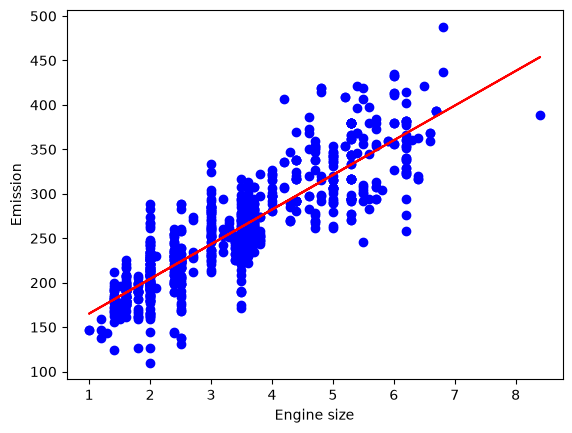

In [15]:
plt.scatter(X_train, y_train,  color='blue')
plt.plot(X_train, regressor.coef_ * X_train + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

#### Đánh giá mô hình (Model evaluation)

Bạn có thể so sánh giá trị thực tế và giá trị dự đoán để tính độ chính xác của một mô hình hồi quy.
Các thước đo đánh giá (evaluation metrics) đóng vai trò quan trọng trong việc phát triển mô hình, vì chúng cung cấp cái nhìn sâu sắc về những điểm cần cải thiện.

Có nhiều thước đo đánh giá mô hình khác nhau.
Ở đây, chúng ta sẽ sử dụng MSE để tính độ chính xác của mô hình dựa trên tập kiểm tra.

• Mean Absolute Error (MAE)

Đây là trung bình của giá trị tuyệt đối sai số.
Đây là thước đo dễ hiểu nhất, vì nó đơn giản là mức sai số trung bình.

• Mean Squared Error (MSE)

MSE là trung bình của bình phương sai số.
Trên thực tế, đây cũng là thước đo mà mô hình sử dụng để tìm ra đường hồi quy tốt nhất, vì vậy nó còn được gọi là:

👉 Residual Sum of Squares (RSS) – tổng bình phương sai số dư.

• Root Mean Squared Error (RMSE)

RMSE chỉ đơn giản là căn bậc hai của MSE.
Nó đưa sai số về cùng đơn vị với biến mục tiêu, giúp việc diễn giải dễ dàng hơn.

• R2-Score (Hệ số xác định)

Đây không phải sai số, mà là một thước đo phổ biến trong đánh giá hồi quy.
Nó cho biết các điểm dữ liệu khớp với đường hồi quy tốt đến mức nào.

R2 càng cao → mô hình càng phù hợp

Giá trị tốt nhất = 1.0

R2 có thể âm, khi mô hình hoạt động tệ hơn cả việc chỉ dự đoán bằng trung bình


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test.reshape(-1,1))

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


✅ 1. Mean Absolute Error (MAE): 24.10

Ý nghĩa:
Sai số trung bình giữa giá trị dự đoán và giá trị thật là 24.10 đơn vị CO₂.

Trung bình, mô hình dự đoán lệch khoảng 24 CO₂ g/km so với thực tế.

MAE thấp → mô hình dự đoán khá chính xác.

✅ 2. Mean Squared Error (MSE): 985.94

Ý nghĩa:
Đây là trung bình bình phương sai số.
MSE luôn lớn hơn MAE vì sai số được bình phương → nhạy cảm với outliers.

MSE ~ 986 cho thấy vẫn có một số điểm sai số lớn tác động lên mô hình.

✅ 3. Root Mean Squared Error (RMSE): 31.40

Ý nghĩa:
Sai số trung bình theo đơn vị CO₂ g/km sau khi đã căn bậc hai MSE.

Trung bình mô hình dự đoán lệch khoảng 31 CO₂ g/km so với thực tế.

💡 RMSE lớn hơn MAE → điều này chứng tỏ có một số outliers làm tăng sai số.

✅ 4. R2-score: 0.76

Ý nghĩa:
R2-score đo lường mức độ mô hình giải thích được sự biến thiên của dữ liệu:

1.0 → hoàn hảo

0 → mô hình không tốt hơn việc đoán theo trung bình

<0 → mô hình rất tệ

Với R2 = 0.76:

Mô hình giải thích được 76% sự biến thiên trong lượng khí thải CO₂.
Đây là một mức khá tốt đối với mô hình simple linear regression với 1 đặc trưng (engine size).

## Practice exercises


#### 1. Vẽ mô hình hồi quy lên dữ liệu kiểm tra thay vì dữ liệu huấn luyện. Hãy đánh giá trực quan xem kết quả có tốt hay không.


Text(0, 0.5, 'Emission')

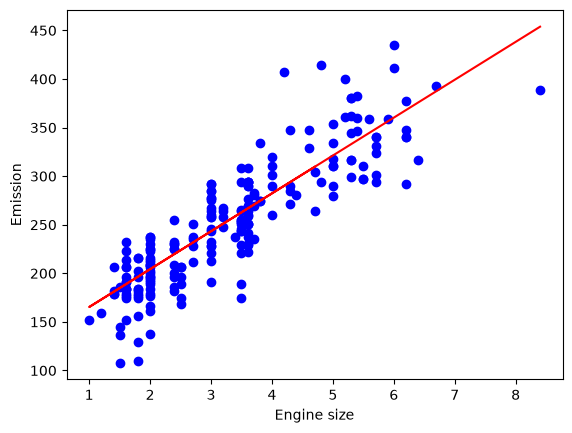

In [21]:
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

**Đánh giá:** Mô hình hoạt động khá tốt. Đường hồi quy tuyến tính vẫn thể hiện rõ xu hướng **CO2EMISSIONS tăng khi ENGINESIZE tăng** và đi qua vùng tập trung chính của dữ liệu. Tuy nhiên, trên biểu đồ vẫn xuất hiện nhiều điểm dữ liệu phân tán và nằm khá xa đường hồi quy, cho thấy **ENGINESIZE chưa thể giải thích hoàn toàn sự biến thiên của CO2EMISSIONS**.

Hãy xem các thước đo đánh giá (evaluation metrics) nếu bạn huấn luyện mô hình hồi quy sử dụng đặc trưng FUELCONSUMPTION_COMB

#### 2. Chọn đặc trưng mức tiêu thụ nhiên liệu FUELCONSUMPTION_COMB từ dataframe và chia dữ liệu theo tỷ lệ 80%/20% thành tập huấn luyện và tập kiểm tra.

Hãy sử dụng cùng random state như trước đó để bạn có thể so sánh một cách khách quan với kết quả huấn luyện trước đây.


In [23]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 3.  Huấn luyện một mô hình hồi quy tuyến tính sử dụng tập dữ liệu huấn luyện mà bạn đã tạo.
Hãy nhớ chuyển đổi đặc trưng một chiều của bạn (1D feature) thành mảng hai chiều (2D array). 


In [29]:
regr = linear_model.LinearRegression()
# Giải thích reshape(-1, 1):
#-1: để NumPy tự động tính số hàng (observations)
#1: số cột (số features = 1) (n_observations, n_features).
# ==> vector 1D thành ma trận 2D.
regr.fit(X_train.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[16.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,69.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[101.33]


#### 4. Sử dụng mô hình để tạo dự đoán trên tập dữ liệu kiểm tra của đặc trưng mức tiêu thụ nhiên liệu.


In [38]:
y = regr.predict(X_test.reshape(-1,1))

#### 5. Tính toán và in ra giá trị Mean Squared Error (MSE) của các dự đoán trên tập kiểm tra.


In [39]:
from sklearn.metrics import root_mean_squared_error

print(f"Mean squared error: {mean_squared_error(y_test, y):,.2f}")
print(f"Root mean squared error: {root_mean_squared_error(y_test, y):,.2f}")


Mean squared error: 797.43
Root mean squared error: 28.24


Như bạn có thể dự đoán từ quá trình phân tích khám phá dữ liệu trước đó, giá trị MSE nhỏ hơn khi chúng ta huấn luyện mô hình bằng đặc trưng FUELCONSUMPTION_COMB so với khi sử dụng ENGINESIZE.


### Congratulations!
 

